# Exploring the Housing Prices Dataset 🏡

This notebook is my take on exploring the famous **House Prices: Advanced Regression Techniques** dataset.  
It’s part of my technical assessment for a Machine Learning internship — and as a final-year CS student still building experience in ML, I’m focusing on learning the practical process behind EDA and preparing data for modelling.

The goal here is to understand the data, clean it properly, explore relationships between features, and get a few ideas that could help when building predictive models later on.

The dataset has two files — `train.csv` and `test.csv`.  
I’ll go through the steps in a logical order: data loading, inspection, cleaning, visualization, and key insights.

---


In [33]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(style='whitegrid', context='notebook')
%matplotlib inline


In [34]:
# Load datasets (assumes files are in /mnt/data)
train_path = Path(r'C:\Users\Jobe\Downloads\house-prices-advanced-regression-techniques\train.csv')
test_path = Path(r'C:\Users\Jobe\Downloads\house-prices-advanced-regression-techniques\test.csv')


train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")

# D
train.head()


Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [35]:
# Data description
desc_path = Path(r'C:\Users\Jobe\Downloads\house-prices-advanced-regression-techniques\data_description.txt')

if desc_path.exists():
    with open(desc_path, 'r', encoding='utf-8') as f:
        desc = f.read()
    print('--- Data description (first 800 characters) ---\n')
    print(desc[:800])
else:
    print('data_description.txt not found in /mnt/data')


--- Data description (first 800 characters) ---

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agricultu


In [36]:
# Data understanding
print('Train columns and dtypes:')
display(train.dtypes)

print('\nTrain shape:', train.shape)
print('Number of duplicate rows in train:', train.duplicated().sum())

# Identify numeric and categorical features (simple heuristic)
numeric_features = train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = train.select_dtypes(exclude=[np.number]).columns.tolist()
print('\nNumeric features (sample):', numeric_features[:10])
print('Categorical features (sample):', categorical_features[:10])

# Missing values report (sorted)
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('\nMissing values (columns with > 0 missing):')
display(missing)


Train columns and dtypes:


Id                 int64
MSSubClass         int64
MSZoning          object
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType          object
SaleCondition     object
SalePrice          int64
Length: 81, dtype: object


Train shape: (1460, 81)
Number of duplicate rows in train: 0

Numeric features (sample): ['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1']
Categorical features (sample): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1']

Missing values (columns with > 0 missing):


PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
FireplaceQu      690
LotFrontage      259
GarageCond        81
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
BsmtExposure      38
BsmtFinType2      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
MasVnrType         8
Electrical         1
dtype: int64

In [37]:
# Data cleaning & preparation (examples and initial handling)
# We'll create a cleaned copy to work with.
df = train.copy()

# 1) Fill LotFrontage by median per Neighborhood if missing
if 'LotFrontage' in df.columns:
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

# 2) Fill categorical missing values with 'None' for features that indicate absence (based on common Kaggle conventions)
fill_none_cols = ['Alley','FireplaceQu','PoolQC','Fence','MiscFeature','GarageType','GarageFinish','GarageQual','GarageCond','MasVnrType']
for c in fill_none_cols:
    if c in df.columns:
        df[c] = df[c].fillna('None')

# 3) Fill numeric garages/masvnr areas with 0 when corresponding type is None
if 'MasVnrArea' in df.columns:
    df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

# 4) For remaining numeric columns, fill with median
num_cols = df.select_dtypes(include=[np.number]).columns
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

# 5) For remaining object columns, fill with mode
obj_cols = df.select_dtypes(include=['object']).columns
for c in obj_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode().iloc[0])

print('Missing values after cleaning (should be 0):', df.isnull().sum().sum())

# Encode a few categorical variables for exploratory correlation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
sample_encode_cols = ['MSZoning','Neighborhood','RoofStyle','Exterior1st','Foundation']
for c in sample_encode_cols:
    if c in df.columns:
        df[c+'_enc'] = le.fit_transform(df[c].astype(str))

# Keep cleaned df for EDA
cleaned = df.copy()
cleaned.shape


Missing values after cleaning (should be 0): 0


(1460, 86)

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

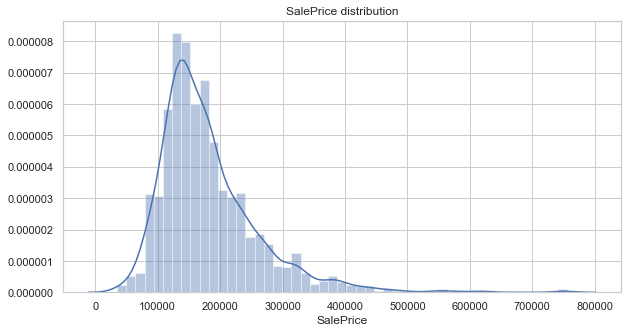

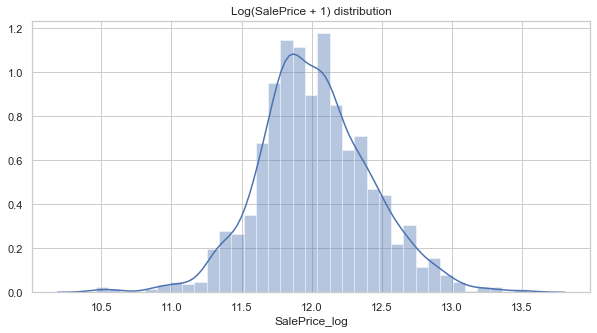

Top correlations with SalePrice:


SalePrice         1.000000
SalePrice_log     0.948374
OverallQual       0.790982
GrLivArea         0.708624
GarageCars        0.640409
GarageArea        0.623431
TotalBsmtSF       0.613581
1stFlrSF          0.605852
FullBath          0.560664
TotRmsAbvGrd      0.533723
YearBuilt         0.522897
YearRemodAdd      0.507101
MasVnrArea        0.472614
Fireplaces        0.466929
GarageYrBlt       0.466754
BsmtFinSF1        0.386420
Foundation_enc    0.382479
LotFrontage       0.349876
WoodDeckSF        0.324413
2ndFlrSF          0.319334
Name: SalePrice, dtype: float64

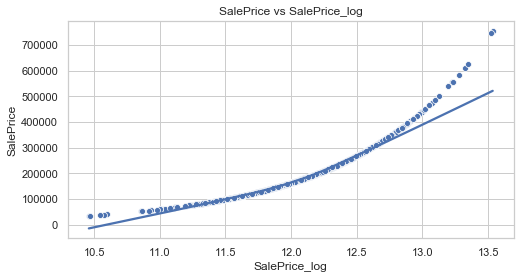

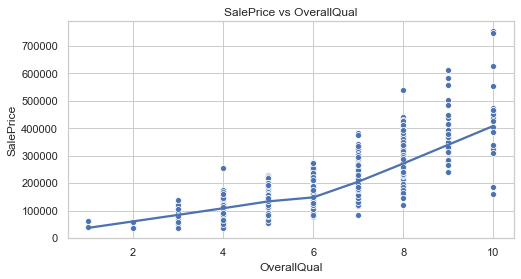

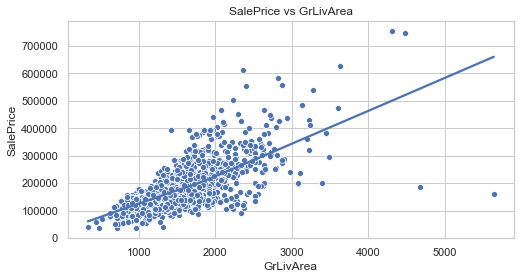

c:\Anaconda3\lib\site-packages\numpy\lib\function_base.py:3405: RuntimeWarning: Invalid value encountered in median
  r = func(a, **kwargs)
c:\Anaconda3\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:165: RuntimeWarning: invalid value encountered in greater_equal
  res = _lowess(y, x, frac=frac, it=it, delta=delta)


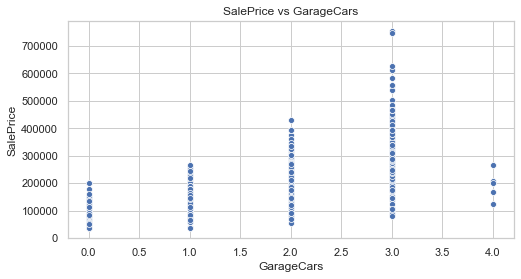

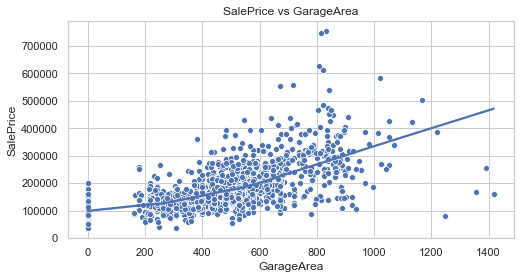

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Descriptive statistics
display(cleaned['SalePrice'].describe())

# Histogram & distribution of SalePrice
plt.figure(figsize=(10,5))
if hasattr(sns, 'histplot'):
    sns.histplot(cleaned['SalePrice'], kde=True)
else:
    sns.distplot(cleaned['SalePrice'], kde=True)  # fallback for older versions
plt.title('SalePrice distribution')
plt.show()

# Log-transform SalePrice
cleaned['SalePrice_log'] = np.log1p(cleaned['SalePrice'])
plt.figure(figsize=(10,5))
if hasattr(sns, 'histplot'):
    sns.histplot(cleaned['SalePrice_log'], kde=True)
else:
    sns.distplot(cleaned['SalePrice_log'], kde=True)
plt.title('Log(SalePrice + 1) distribution')
plt.show()

# Correlation heatmap (top correlations with SalePrice)
corrmat = cleaned.corr()
top_corr = corrmat['SalePrice'].abs().sort_values(ascending=False).head(20)
print('Top correlations with SalePrice:')
display(top_corr)

# Visualize relationship between SalePrice and top numeric features
top_feats = top_corr.index[1:6].tolist()  # skip SalePrice itself
for feat in top_feats:
    plt.figure(figsize=(8,4))
    sns.scatterplot(data=cleaned, x=feat, y='SalePrice')
    sns.regplot(data=cleaned, x=feat, y='SalePrice', scatter=False, lowess=True)
    plt.title(f'SalePrice vs {feat}')
    plt.show()


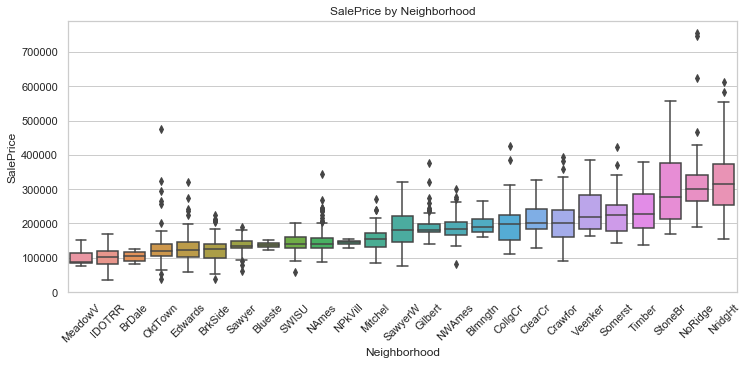

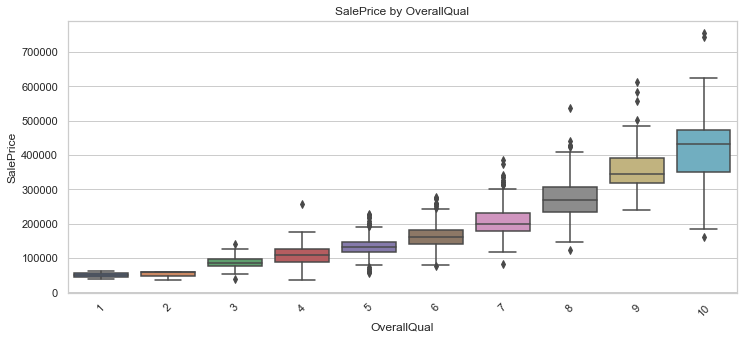

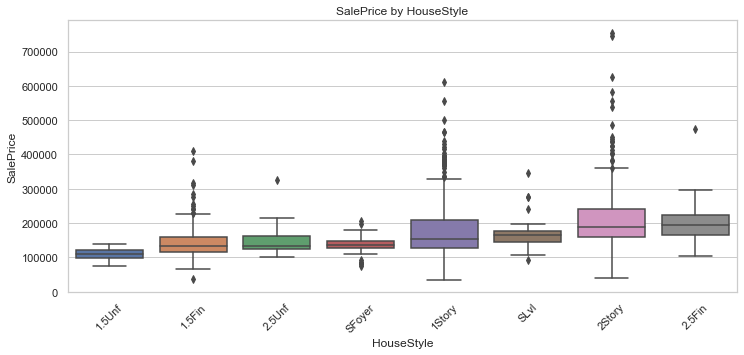

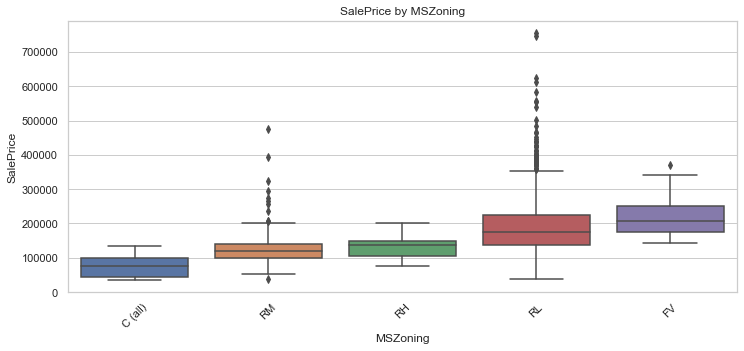

In [39]:
# Categorical analysis: SalePrice by categorical features (boxplots for a few important categories)
cat_features = ['Neighborhood','OverallQual','HouseStyle','MSZoning']
for c in cat_features:
    if c in cleaned.columns:
        plt.figure(figsize=(12,5))
        order = cleaned.groupby(c)['SalePrice'].median().sort_values().index
        sns.boxplot(data=cleaned, x=c, y='SalePrice', order=order)
        plt.xticks(rotation=45)
        plt.title(f'SalePrice by {c}')
        plt.show()


# Insights and Reflections 💡

After spending time exploring the dataset, a few interesting things stood out:

- **Correlations:** Features like `OverallQual`, `GrLivArea`, `GarageCars`, and `TotalBsmtSF` have the strongest positive relationships with `SalePrice`. These are definitely key predictors to focus on.  
- **Price distribution:** The target variable `SalePrice` is noticeably right-skewed. Applying a log transformation helps make it more normally distributed, which is usually better for regression models.  
- **Missing values:** Some columns like `Alley`, `FireplaceQu`, `PoolQC`, and others have many missing entries — but these mostly represent *absence* (e.g., no pool, no fireplace), so I filled them with `'None'`. For numeric ones, I used the median to avoid outlier influence.  
- **Categorical effects:** Neighborhood and overall quality (`OverallQual`) seem to have clear effects on house prices — they could be very useful when we build the model.

### What I’d do next (Feature ideas & Modelling plan)
- Combine related features like `TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF` to capture total space.  
- Create `Age = YrSold - YearBuilt` and maybe `RemodAge = YrSold - YearRemodAdd` to capture aging effects.  
- Use one-hot or target encoding for categorical columns depending on model type.  
- Definitely log-transform `SalePrice` and other skewed numeric features before training.

These observations should make the modelling phase smoother and improve prediction accuracy.

---


# Optional Extensions 🚀

If I had more time, I’d like to go further by experimenting with:
- Extra **feature engineering**, such as interactions between key numeric features.
- Trying out a **simple Linear Regression** or **Random Forest** just to get a feel of baseline performance (RMSE, R²).

Some commented-out cells below already include the basic structure for that.  
Overall, this EDA gave me a solid understanding of the dataset and what matters most before moving into model training.


In [40]:
# Save artifacts
summary = cleaned.corr()['SalePrice'].abs().sort_values(ascending=False).head(30)
summary.to_csv('/mnt/data/top_correlations_saleprice.csv', index=True)
cleaned.to_csv('/mnt/data/cleaned_train_sample.csv', index=False)
print('Saved /mnt/data/top_correlations_saleprice.csv and /mnt/data/cleaned_train_sample.csv')


c:\Anaconda3\lib\site-packages\ipykernel_launcher.py:3: FutureWarning: The signature of `Series.to_csv` was aligned to that of `DataFrame.to_csv`, and argument 'header' will change its default value from False to True: please pass an explicit value to suppress this warning.
  This is separate from the ipykernel package so we can avoid doing imports until


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/top_correlations_saleprice.csv'